**Data Loading & Initial Subsetting**

In [81]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [82]:
path = '/content/drive/MyDrive/Data Projects/Olist'

In [83]:
!ls "{path}"

olist_customers.csv	  olist_orders.csv
olist_geolocation.csv	  olist_products.csv
olist_order_items.csv	  olist_sellers.csv
olist_order_payments.csv  product_category_name_translation.csv
olist_order_reviews.csv


In [84]:
import pandas as pd

orders=pd.read_csv(path+'/olist_orders.csv')
order_items =pd.read_csv(path+'/olist_order_items.csv')
reviews =pd.read_csv(path+'/olist_order_reviews.csv')
products=pd.read_csv(path+'/olist_products.csv')
sellers=pd.read_csv(path+'/olist_sellers.csv')
category_translation =pd.read_csv(path+'/product_category_name_translation.csv')

In [85]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [86]:
orders=orders[['order_id','order_status','order_purchase_timestamp','order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date']]

In [87]:
order_items .info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [88]:
order_items =order_items[['order_id','order_item_id','product_id','seller_id','price','freight_value']]

In [89]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [90]:
products=products[['product_id','product_category_name']]

In [91]:
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [92]:
reviews=reviews[['order_id','review_score']]

In [93]:
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [94]:
sellers=sellers[['seller_id','seller_state']]

In [95]:
category_translation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


**Cleaning up data types & dates**

In [96]:
date_columns=['order_purchase_timestamp','order_delivered_carrier_date',
              'order_delivered_customer_date','order_estimated_delivery_date']
for col in date_columns:
  orders[col]=pd.to_datetime(orders[col])
print(orders[date_columns].dtypes)

order_purchase_timestamp         datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


**Checking nulls and missing info**

In [97]:

print("Orders Nulls:\n", orders.isna().sum().loc[lambda x: x > 0])
print("\nProducts Nulls:\n", products.isna().sum().loc[lambda x: x > 0])
print("\nOrder Items Nulls:", order_items.isna().sum().loc[lambda x: x > 0])

print("Sellers Nulls:", sellers.isna().sum().loc[lambda x: x > 0])
print("Reviews Nulls:", reviews.isna().sum().loc[lambda x: x > 0])

print("Category Translation Nulls:", category_translation.isna().sum().loc[lambda x: x > 0])

Orders Nulls:
 order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Products Nulls:
 product_category_name    610
dtype: int64

Order Items Nulls: Series([], dtype: int64)
Sellers Nulls: Series([], dtype: int64)
Reviews Nulls: Series([], dtype: int64)
Category Translation Nulls: Series([], dtype: int64)


In [98]:
products.fillna({'product_category_name':'unknown'},inplace=True)

**Checking for weird prices or time-traveling orders**

In [99]:
order_items[['price','freight_value']].describe()

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [100]:
print("Number of zero or negative price",len(order_items[order_items['price']<=0]))

Number of zero or negative price 0


Removed 189 'Time Traveler' orders with impossible dates to prevent negative values from skewing the analysis

In [101]:
time_travelers = orders[(orders['order_delivered_customer_date'] < orders['order_purchase_timestamp'] ) |
                        (orders['order_delivered_customer_date'] < orders['order_delivered_carrier_date']) |
                        (orders['order_delivered_carrier_date'] < orders['order_purchase_timestamp']) |
                        (orders['order_estimated_delivery_date'] < orders['order_purchase_timestamp'])
                        ]
print(f"Number of broken orders: {len(time_travelers)}")

ids=time_travelers['order_id'].unique()
orders = orders.drop(time_travelers.index).reset_index(drop=True)
order_items=order_items[~order_items['order_id'].isin(ids)].reset_index(drop=True)
reviews=reviews[~reviews['order_id'].isin(ids)].reset_index(drop=True)


Number of broken orders: 189


**Checking IDs and duplicates**

In [102]:
print("Orders:  ", len(orders), orders.order_id.nunique())
print("Items:   ", len(order_items), order_items.order_id.nunique())
print("Products:", len(products), products.product_id.nunique())
print("Sellers: ", len(sellers), sellers.seller_id.nunique())
print("Reviews: ", len(reviews), reviews.order_id.nunique())

Orders:   99252 99252
Items:    112413 98477
Products: 32951 32951
Sellers:  3095 3095
Reviews:  99036 98485


In [103]:
print("Item Dups:   ", order_items.duplicated(['order_id','order_item_id']).sum())
print("review dups: ",reviews.duplicated().sum())

Item Dups:    0
review dups:  349


**Verifying joins between tables**

In [104]:
orphan_orders=orders[~orders['order_id'].isin(order_items['order_id'])]
print("Orders with no items",len(orphan_orders))
print(orphan_orders['order_status'].value_counts())

print("Items with no order match:",len(order_items[~order_items['order_id'].isin(orders['order_id'])]))

Orders with no items 775
order_status
unavailable    603
canceled       164
created          5
invoiced         2
shipped          1
Name: count, dtype: int64
Items with no order match: 0


In [105]:
no_delivery=orders[orders['order_delivered_customer_date'].isnull()]
missing_items=no_delivery[~no_delivery['order_id'].isin(order_items['order_id'])]
print("orders with no delivery date",len(no_delivery))
print("missing from items",len(missing_items))

orders with no delivery date 2964
missing from items 775


In [106]:
orphan_items = order_items[~order_items['product_id'].isin(products['product_id'])]
print("Orphaned Product IDs:",len(orphan_items))

orphan_sellers = order_items[~order_items['seller_id'].isin(sellers['seller_id'])]
print("Orphaned Seller IDs: ",len(orphan_sellers))

unlinked_reviews = reviews[~reviews['order_id'].isin(orders['order_id'])]
print("Unlinked Review Records:",len(unlinked_reviews))

missing_categories=products[~products['product_category_name'].isin(category_translation['product_category_name'])]
print("Unique missing categories",missing_categories['product_category_name'].nunique())
print("Distinct values are:",missing_categories['product_category_name'].value_counts())


Orphaned Product IDs: 0
Orphaned Seller IDs:  0
Unlinked Review Records: 0
Unique missing categories 3
Distinct values are: product_category_name
unknown                                          610
portateis_cozinha_e_preparadores_de_alimentos     10
pc_gamer                                           3
Name: count, dtype: int64


In [107]:
unsold_products = products[~products['product_id'].isin(order_items['product_id'])]
print("Unsold Products:   ", len(unsold_products))

inactive_sellers = sellers[~sellers['seller_id'].isin(order_items['seller_id'])]
print("Inactive Sellers:  ", len(inactive_sellers))

no_rev= orders[~orders['order_id'].isin(reviews['order_id'])]
no_oi=orders[~orders['order_id'].isin(order_items['order_id'])]

items_no_review = no_rev[~no_rev.order_id.isin(no_oi.order_id)]
review_no_item = no_oi[~no_oi.order_id.isin(no_rev.order_id)]

print("Orders with no reviews: ",len(no_rev))
print("Items with no review:   ", len(items_no_review))
print("Reviews with no item:   ", len(review_no_item))
print("Both missing:           ", len(no_rev) - len(items_no_review))

Unsold Products:    61
Inactive Sellers:   5
Orders with no reviews:  767
Items with no review:    748
Reviews with no item:    756
Both missing:            19


**Fixing missing categories**

In [108]:
category_translation.loc[len(category_translation)]=["unknown","unknown"]
category_translation.loc[len(category_translation)]=["pc_gamer","gaming_pc"]
category_translation.loc[len(category_translation)]=["portateis_cozinha_e_preparadores_de_alimentos","kitchen_appliances"]

In [109]:
reviews=reviews.groupby('order_id')['review_score'].mean().round(1).reset_index()
print(reviews['order_id'].nunique())
print('length of reviews',len(reviews))

98485
length of reviews 98485


In [110]:
orders[(orders['order_status'] == 'delivered') & (orders['order_delivered_customer_date'].isnull())]

,order_id,order_status,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
2996,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-30 18:12:23,NaT,2017-12-18
20575,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-25 08:05:00,NaT,2018-07-16
43749,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-03 13:57:00,NaT,2018-07-30
79114,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-03 13:57:00,NaT,2018-07-30
82711,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-03 09:28:00,NaT,2018-07-24
92468,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,NaT,NaT,2017-06-23
97466,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-12 14:10:00,NaT,2018-06-26
97856,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-07-03 19:26:00,NaT,2018-07-19


**Duck db**

In [111]:
!pip install duckdb

In [112]:
import duckdb

In [113]:
duckdb.sql("""
CREATE OR REPLACE VIEW sales AS
SELECT
    oi.order_id,
    oi.order_item_id,
    oi.product_id,
    oi.seller_id,
    oi.price,
    oi.freight_value,
    o.order_status,
    o.order_purchase_timestamp,
    o.order_delivered_carrier_date,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    p.product_category_name,
    ct.product_category_name_english,
    s.seller_state,
    r.review_score
FROM order_items oi
LEFT JOIN orders o ON oi.order_id = o.order_id
LEFT JOIN products p ON oi.product_id = p.product_id
LEFT JOIN category_translation ct ON p.product_category_name = ct.product_category_name
LEFT JOIN reviews r ON oi.order_id = r.order_id
LEFT JOIN sellers s ON oi.seller_id = s.seller_id
""")

In [114]:
duckdb.sql("""
select count(*) as count,count(distinct order_id) as unique_orderid_cnt,sum(case when review_score is null then 1 else 0 end) as null_review_cnt from sales
""").show()

┌────────┬────────────────────┬─────────────────┐
│ count  │ unique_orderid_cnt │ null_review_cnt │
│ int64  │       int64        │     int128      │
├────────┼────────────────────┼─────────────────┤
│ 112413 │              98477 │             940 │
└────────┴────────────────────┴─────────────────┘



In [115]:
duckdb.sql("""
select count(*),review_score from sales group by review_score order by review_score desc
""").show()

┌──────────────┬──────────────┐
│ count_star() │ review_score │
│    int64     │    double    │
├──────────────┼──────────────┤
│        62958 │          5.0 │
│           68 │          4.5 │
│            1 │          4.3 │
│        21115 │          4.0 │
│           31 │          3.5 │
│            1 │          3.3 │
│         9367 │          3.0 │
│           45 │          2.5 │
│         3825 │          2.0 │
│           18 │          1.5 │
│        14044 │          1.0 │
│          940 │         NULL │
├──────────────┴──────────────┤
│ 12 rows           2 columns │
└─────────────────────────────┘



In [116]:
duckdb.sql("""
select * from sales limit 5
""").show()

┌──────────────────────────────────┬───────────────┬──────────────────────────────────┬──────────────────────────────────┬────────┬───────────────┬──────────────┬──────────────────────────┬──────────────────────────────┬───────────────────────────────┬───────────────────────────────┬───────────────────────┬───────────────────────────────┬──────────────┬──────────────┐
│             order_id             │ order_item_id │            product_id            │            seller_id             │ price  │ freight_value │ order_status │ order_purchase_timestamp │ order_delivered_carrier_date │ order_delivered_customer_date │ order_estimated_delivery_date │ product_category_name │ product_category_name_english │ seller_state │ review_score │
│             varchar              │     int64     │             varchar              │             varchar              │ double │    double     │   varchar    │       timestamp_ns       │         timestamp_ns         │         timestamp_ns          │      

In [117]:
duckdb.sql("""
select product_category_name,round(sum(price),2) as total_amount from sales group by product_category_name order by round(sum(price),2) desc limit 5
""").show()

┌────────────────────────┬──────────────┐
│ product_category_name  │ total_amount │
│        varchar         │    double    │
├────────────────────────┼──────────────┤
│ beleza_saude           │   1257059.78 │
│ relogios_presentes     │   1202869.52 │
│ cama_mesa_banho        │   1035114.73 │
│ esporte_lazer          │    986309.03 │
│ informatica_acessorios │    910890.81 │
└────────────────────────┴──────────────┘



In [118]:
duckdb.sql("""
select order_status,count(*) from sales group by order_status
""").show()

┌──────────────┬──────────────┐
│ order_status │ count_star() │
│   varchar    │    int64     │
├──────────────┼──────────────┤
│ delivered    │       109961 │
│ invoiced     │          359 │
│ canceled     │          542 │
│ shipped      │         1184 │
│ processing   │          357 │
│ approved     │            3 │
│ unavailable  │            7 │
└──────────────┴──────────────┘



In [119]:
duckdb.sql("""
SELECT
    order_status,
    COUNT(*) AS total_orders
FROM orders
WHERE  order_delivered_carrier_date IS NULL
GROUP BY 1
ORDER BY 2 DESC;
""")

┌──────────────┬──────────────┐
│ order_status │ total_orders │
│   varchar    │    int64     │
├──────────────┼──────────────┤
│ unavailable  │          609 │
│ canceled     │          550 │
│ invoiced     │          314 │
│ processing   │          301 │
│ created      │            5 │
│ approved     │            2 │
│ delivered    │            2 │
└──────────────┴──────────────┘

In [120]:
duckdb.sql("""
select order_status,count(*) from sales where order_delivered_customer_date is not null  group by order_status
""").show()

┌──────────────┬──────────────┐
│ order_status │ count_star() │
│   varchar    │    int64     │
├──────────────┼──────────────┤
│ delivered    │       109953 │
│ canceled     │            7 │
└──────────────┴──────────────┘



In [121]:
duckdb.sql("""
select * from sales where order_status='delivered' and  order_delivered_customer_date is null
""").show()

┌──────────────────────────────────┬───────────────┬──────────────────────────────────┬──────────────────────────────────┬────────┬───────────────┬──────────────┬──────────────────────────┬──────────────────────────────┬───────────────────────────────┬───────────────────────────────┬───────────────────────────────┬────────────────────────────────┬──────────────┬──────────────┐
│             order_id             │ order_item_id │            product_id            │            seller_id             │ price  │ freight_value │ order_status │ order_purchase_timestamp │ order_delivered_carrier_date │ order_delivered_customer_date │ order_estimated_delivery_date │     product_category_name     │ product_category_name_english  │ seller_state │ review_score │
│             varchar              │     int64     │             varchar              │             varchar              │ double │    double     │   varchar    │       timestamp_ns       │         timestamp_ns         │         timestamp_n

**DELIVERY ANALYSIS**

In [122]:
duckdb.sql("""
CREATE OR REPLACE VIEW sales_delivered AS
SELECT *,
    DATE_DIFF('day', order_purchase_timestamp, order_delivered_carrier_date) AS purchase_to_carrier_days,
    DATE_DIFF('day', order_estimated_delivery_date, order_delivered_customer_date) AS delivery_delay_days,
    DATE_DIFF('day', order_delivered_carrier_date, order_delivered_customer_date) AS transit_time_days
FROM sales
WHERE order_status = 'delivered'
AND order_delivered_customer_date IS NOT NULL;
""")
#Data Quality Note:
#8 orders have status = 'delivered' but no delivery date recorded.
#This is contradictory — a delivered order must have a delivery timestamp.

In [123]:
duckdb.sql("""
SELECT
    COUNT(*) AS total_orders,

    SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) AS late_orders,

    SUM(CASE WHEN order_delivered_carrier_date > order_estimated_delivery_date THEN 1 ELSE 0 END) AS warehouse_late,

    (SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) -
     SUM(CASE WHEN order_delivered_carrier_date > order_estimated_delivery_date THEN 1 ELSE 0 END)) AS carrier_late,

    ROUND(100.0 * SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) AS LDR
FROM sales_delivered
""").show()

┌──────────────┬─────────────┬────────────────┬──────────────┬────────┐
│ total_orders │ late_orders │ warehouse_late │ carrier_late │  LDR   │
│    int64     │   int128    │     int128     │    int128    │ double │
├──────────────┼─────────────┼────────────────┼──────────────┼────────┤
│       109953 │        7262 │            536 │         6726 │    6.6 │
└──────────────┴─────────────┴────────────────┴──────────────┴────────┘



In [124]:
duckdb.sql("""
SELECT
    MIN(delivery_delay_days) AS min_delay,
    MAX(delivery_delay_days) AS max_delay,
    ROUND(AVG(delivery_delay_days),2) AS avg_delay,
    MEDIAN(delivery_delay_days) AS median_delay,
    ROUND(STDDEV(delivery_delay_days),2) AS std_dev_delay,
    QUANTILE_CONT(delivery_delay_days, 0.9) AS p90_delay
FROM sales_delivered
WHERE delivery_delay_days > 0;
""").show()

┌───────────┬───────────┬───────────┬──────────────┬───────────────┬───────────┐
│ min_delay │ max_delay │ avg_delay │ median_delay │ std_dev_delay │ p90_delay │
│   int64   │   int64   │  double   │    double    │    double     │  double   │
├───────────┼───────────┼───────────┼──────────────┼───────────────┼───────────┤
│         1 │       188 │     10.49 │          7.0 │          14.5 │      22.0 │
└───────────┴───────────┴───────────┴──────────────┴───────────────┴───────────┘



In [125]:
duckdb.sql("""
SELECT
  CASE
    WHEN delivery_delay_days BETWEEN 1 AND 3 THEN '01-03 days (Minor)'
    WHEN delivery_delay_days BETWEEN 4 AND 7 THEN '04-07 days (Moderate)'
    WHEN delivery_delay_days BETWEEN 8 AND 14 THEN '08-14 days (Serious)'
    ELSE '15+ days (Critical)'
END AS delay_bucket,
COUNT(*) AS order_count,
ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) AS percentage
FROM sales_delivered
WHERE delivery_delay_days>0
GROUP BY 1
ORDER BY 1
""").show()

┌───────────────────────┬─────────────┬────────────┐
│     delay_bucket      │ order_count │ percentage │
│        varchar        │    int64    │   double   │
├───────────────────────┼─────────────┼────────────┤
│ 01-03 days (Minor)    │        2109 │      29.04 │
│ 04-07 days (Moderate) │        2006 │      27.62 │
│ 08-14 days (Serious)  │        1617 │      22.27 │
│ 15+ days (Critical)   │        1530 │      21.07 │
└───────────────────────┴─────────────┴────────────┘



In [126]:
duckdb.sql("""
select min(order_purchase_timestamp) as mm,max(order_purchase_timestamp) as jj from sales_delivered""").show()

┌─────────────────────┬─────────────────────┐
│         mm          │         jj          │
│    timestamp_ns     │    timestamp_ns     │
├─────────────────────┼─────────────────────┤
│ 2016-09-15 12:16:38 │ 2018-08-29 15:00:37 │
└─────────────────────┴─────────────────────┘



In [127]:
master_analysis = duckdb.sql("""
SELECT
    STRFTIME(order_purchase_timestamp,'%Y-%m') as ym,
    COUNT(order_id) as total_orders,
    AVG(transit_time_days) as carrier_speed,
    AVG(freight_value) as avg_freight,
    ROUND(100.0 * SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) / COUNT(order_id), 2) as LDR,
FROM sales_delivered
WHERE STRFTIME(order_purchase_timestamp,'%Y-%m') BETWEEN '2017-01' AND '2018-08'
GROUP BY 1
ORDER BY 1
""").df()

print(master_analysis.corr(numeric_only=True))

               total_orders  carrier_speed  avg_freight       LDR
total_orders       1.000000       0.048358     0.423734  0.514356
carrier_speed      0.048358       1.000000    -0.481055  0.719954
avg_freight        0.423734      -0.481055     1.000000 -0.052870
LDR                0.514356       0.719954    -0.052870  1.000000


*Extreme Delay Outliers (30+ days)*

In [128]:
duckdb.sql("""
SELECT
    COUNT(*) as total_orders,
    ROUND(100.0 * COUNT(*) / (SELECT COUNT(*) FROM sales_delivered WHERE delivery_delay_days > 0), 2) as pct_of_late_orders,
    MAX(delivery_delay_days) as worst_case
FROM sales_delivered
WHERE delivery_delay_days > 30
""").show()

┌──────────────┬────────────────────┬────────────┐
│ total_orders │ pct_of_late_orders │ worst_case │
│    int64     │       double       │   int64    │
├──────────────┼────────────────────┼────────────┤
│          369 │               5.08 │        188 │
└──────────────┴────────────────────┴────────────┘



LDR rose sharply between Dec 2017 and Apr 2018 amid higher order volumes.

In [129]:
ldr_df=duckdb.sql("""
SELECT
  STRFTIME(order_delivered_customer_date,'%Y-%m') as year_month,
  COUNT(*) as total_orders,
  ROUND(100 * SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END)/ COUNT(*),2) as LDR
FROM sales_delivered
WHERE order_delivered_customer_date >= '2017-01-01' AND order_delivered_customer_date < '2018-09-01'
GROUP BY 1
ORDER BY 1
""").df()
ldr_df

,year_month,total_orders,LDR
0,2017-01,326,0.00
1,2017-02,1559,0.06
2,2017-03,2722,2.06
3,2017-04,2072,5.31
4,2017-05,4201,4.64
5,2017-06,3636,2.94
6,2017-07,3908,3.10
7,2017-08,4892,2.17
8,2017-09,4496,3.67
9,2017-10,5215,3.97


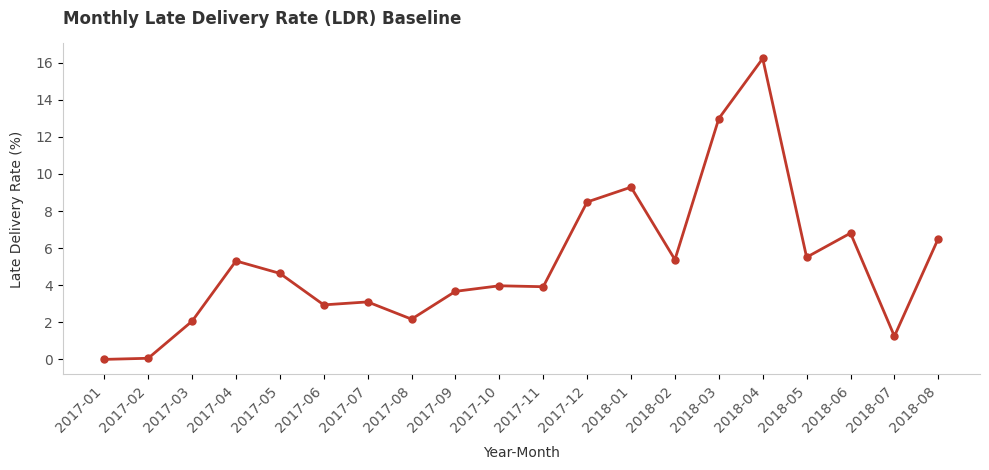

In [130]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4.8))

plt.plot(ldr_df['year_month'], ldr_df['LDR'], marker='o', linewidth=2, color='#c0392b', markersize=5)

plt.title('Monthly Late Delivery Rate (LDR) Baseline', fontsize=12, fontweight='bold', pad=14, loc='left', color='#333333')
plt.xlabel('Year-Month', fontsize=10, labelpad=8, color='#333333')
plt.ylabel('Late Delivery Rate (%)', fontsize=10, labelpad=8, color='#333333')

plt.xticks(rotation=45, ha='right', color='#555555')
plt.yticks(color='#555555')

plt.grid(False)
plt.gca().spines[['top', 'right']].set_visible(False)

plt.gca().spines[['left', 'bottom']].set_color('#cccccc')

plt.tight_layout()
plt.show()

Spike was platform-wide not category-specific — pointing to a logistics issue not a supplier failure.

In [131]:
duckdb.sql("""
SELECT
    product_category_name_english,
    COUNT(*) as total_orders,
    ROUND(100.0 * SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) as LDR,
FROM sales_delivered
WHERE STRFTIME(order_delivered_customer_date,'%Y-%m') IN ('2018-03','2018-04')
GROUP BY 1
HAVING COUNT(*) >= 100
ORDER BY LDR DESC
LIMIT 10
""").show()

┌───────────────────────────────┬──────────────┬────────┐
│ product_category_name_english │ total_orders │  LDR   │
│            varchar            │    int64     │ double │
├───────────────────────────────┼──────────────┼────────┤
│ watches_gifts                 │          822 │  19.71 │
│ electronics                   │          563 │  18.29 │
│ bed_bath_table                │         1589 │  17.56 │
│ stationery                    │          348 │  17.24 │
│ telephony                     │          692 │  16.76 │
│ health_beauty                 │         1378 │  16.11 │
│ consoles_games                │          119 │  15.97 │
│ garden_tools                  │          553 │  15.73 │
│ sports_leisure                │         1447 │   15.2 │
│ computers_accessories         │         1740 │  15.17 │
├───────────────────────────────┴──────────────┴────────┤
│ 10 rows                                     3 columns │
└───────────────────────────────────────────────────────┘



In [132]:
duckdb.sql("""
SELECT
    seller_state,
    COUNT(*) as total_orders
FROM sales_delivered
GROUP BY 1
ORDER BY total_orders ASC
""").show()

┌──────────────┬──────────────┐
│ seller_state │ total_orders │
│   varchar    │    int64     │
├──────────────┼──────────────┤
│ AM           │            3 │
│ PA           │            8 │
│ SE           │           10 │
│ PI           │           11 │
│ RO           │           14 │
│ PB           │           37 │
│ MS           │           50 │
│ RN           │           56 │
│ CE           │           90 │
│ MT           │          144 │
│ ES           │          364 │
│ MA           │          398 │
│ PE           │          445 │
│ GO           │          507 │
│ BA           │          623 │
│ DF           │          882 │
│ RS           │         2164 │
│ SC           │         3989 │
│ RJ           │         4678 │
│ PR           │         8472 │
│ MG           │         8575 │
│ SP           │        78433 │
├──────────────┴──────────────┤
│ 22 rows           2 columns │
└─────────────────────────────┘



Note: 9 seller states were excluded from this analysis due to
insufficient order volume (< 100 orders). Results represent
states with statistically meaningful delivery data.

MA has the highest LDR at 19.6% (3x the baseline), while SP is the biggest problem, driving 78k orders at a high 7.12% LDR.

In [133]:
duckdb.sql("""
SELECT
seller_state,
COUNT(*) as total_orders,
ROUND(100 * SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END)/ COUNT(*), 2) LDR
FROM sales_delivered
GROUP BY 1
HAVING count(*) >= 100
ORDER BY LDR DESC
""").show()

┌──────────────┬──────────────┬────────┐
│ seller_state │ total_orders │  LDR   │
│   varchar    │    int64     │ double │
├──────────────┼──────────────┼────────┤
│ MA           │          398 │   19.6 │
│ SP           │        78433 │   7.12 │
│ RJ           │         4678 │   6.93 │
│ DF           │          882 │   6.01 │
│ ES           │          364 │   5.77 │
│ PR           │         8472 │   5.31 │
│ SC           │         3989 │   4.86 │
│ MG           │         8575 │   4.79 │
│ BA           │          623 │   4.49 │
│ MT           │          144 │   4.17 │
│ PE           │          445 │   3.37 │
│ RS           │         2164 │   3.23 │
│ GO           │          507 │   2.56 │
├──────────────┴──────────────┴────────┤
│ 13 rows                    3 columns │
└──────────────────────────────────────┘



In [134]:
duckdb.sql("""
SELECT
    product_category_name_english,
    COUNT(*) as total_orders
FROM sales_delivered
WHERE product_category_name_english != 'unknown'
GROUP BY 1
ORDER BY total_orders ASC
""").show()

┌───────────────────────────────┬──────────────┐
│ product_category_name_english │ total_orders │
│            varchar            │    int64     │
├───────────────────────────────┼──────────────┤
│ security_and_services         │            2 │
│ fashion_childrens_clothes     │            7 │
│ gaming_pc                     │            8 │
│ kitchen_appliances            │           14 │
│ cds_dvds_musicals             │           14 │
│ la_cuisine                    │           14 │
│ arts_and_craftmanship         │           24 │
│ fashion_sport                 │           29 │
│ home_comfort_2                │           30 │
│ flowers                       │           33 │
│  ·                            │            · │
│  ·                            │            · │
│  ·                            │            · │
│ auto                          │         4120 │
│ garden_tools                  │         4259 │
│ telephony                     │         4425 │
│ watches_gifts     

In [135]:
duckdb.sql("""
SELECT
  product_category_name_english,
  COUNT(*) as total_orders,
  ROUND(100 * SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END)/ COUNT(*),2) as LDR
FROM sales_delivered
WHERE product_category_name_english != 'unknown'
GROUP BY 1
HAVING total_orders > 500
ORDER BY LDR DESC
LIMIT 10
""").show()

┌───────────────────────────────┬──────────────┬────────┐
│ product_category_name_english │ total_orders │  LDR   │
│            varchar            │    int64     │ double │
├───────────────────────────────┼──────────────┼────────┤
│ office_furniture              │         1667 │   7.98 │
│ baby                          │         2977 │   7.69 │
│ electronics                   │         2724 │    7.6 │
│ health_beauty                 │         9447 │   7.58 │
│ musical_instruments           │          650 │   7.38 │
│ watches_gifts                 │         5846 │   7.22 │
│ furniture_decor               │         8133 │   7.06 │
│ bed_bath_table                │        10929 │   7.05 │
│ auto                          │         4120 │   7.04 │
│ telephony                     │         4425 │   6.96 │
├───────────────────────────────┴──────────────┴────────┤
│ 10 rows                                     3 columns │
└───────────────────────────────────────────────────────┘



In [136]:
duckdb.sql("""
CREATE OR REPLACE VIEW sales_reviewed AS
SELECT * FROM sales_delivered
WHERE review_score IS NOT NULL
""")

Late deliveries generate bad reviews at 5.5x the rate of on-time orders, causing the average review score to plummet from 4.21 to 2.26.

In [137]:
duckdb.sql("""
SELECT
    CASE WHEN delivery_delay_days > 0 THEN 'Late' ELSE 'On Time' END AS delivery_status,
    COUNT(*) as total_orders,
    ROUND(AVG(review_score), 2) as avg_review_score,
    ROUND(100.0 * SUM(CASE WHEN review_score <= 2 THEN 1 ELSE 0 END) / COUNT(*), 2) as pct_bad_reviews
FROM sales_reviewed
GROUP BY 1
ORDER BY 1
""").show()

┌─────────────────┬──────────────┬──────────────────┬─────────────────┐
│ delivery_status │ total_orders │ avg_review_score │ pct_bad_reviews │
│     varchar     │    int64     │      double      │     double      │
├─────────────────┼──────────────┼──────────────────┼─────────────────┤
│ Late            │         7081 │             2.26 │           62.89 │
│ On Time         │       102047 │             4.21 │           11.38 │
└─────────────────┴──────────────┴──────────────────┴─────────────────┘



In [138]:
duckdb.sql("""
SELECT
    CASE WHEN delivery_delay_days > 0 THEN 'Late' ELSE 'On Time' END AS delivery_status,
    COUNT(*) as total_orders,
    ROUND(SUM(price + freight_value), 2) as total_revenue,
    ROUND(100.0 * SUM(price + freight_value) / SUM(SUM(price + freight_value)) OVER(), 2) as pct_of_revenue
FROM sales_delivered
GROUP BY 1
ORDER BY 1
""").show()

┌─────────────────┬──────────────┬───────────────┬────────────────┐
│ delivery_status │ total_orders │ total_revenue │ pct_of_revenue │
│     varchar     │    int64     │    double     │     double     │
├─────────────────┼──────────────┼───────────────┼────────────────┤
│ Late            │         7262 │    1150711.47 │           7.48 │
│ On Time         │       102691 │   14240166.28 │          92.52 │
└─────────────────┴──────────────┴───────────────┴────────────────┘



> Median review score drops from 4.0 to 3.0 at day 2, and hits 2.0 at day 3. Intervene within 48 hours of a missed delivery before the customer is completely lost.

In [139]:
deli_df=duckdb.sql("""
SELECT
    delivery_delay_days,
    ROUND(AVG(review_score), 2) as avg_review_score,
    ROUND(MEDIAN(review_score),2) as med_review_score,
    COUNT(*) as total_orders
FROM sales_reviewed
WHERE delivery_delay_days BETWEEN 1 AND 30
GROUP BY 1
ORDER BY 1
""").df()
deli_df

,delivery_delay_days,avg_review_score,med_review_score,total_orders
0,1,3.68,4.0,931
1,2,3.15,3.0,591
2,3,2.58,2.0,565
3,4,2.52,2.0,477
4,5,2.14,1.0,492
5,6,1.82,1.0,438
6,7,1.89,1.0,535
7,8,1.70,1.0,370
8,9,1.74,1.0,240
9,10,1.56,1.0,223


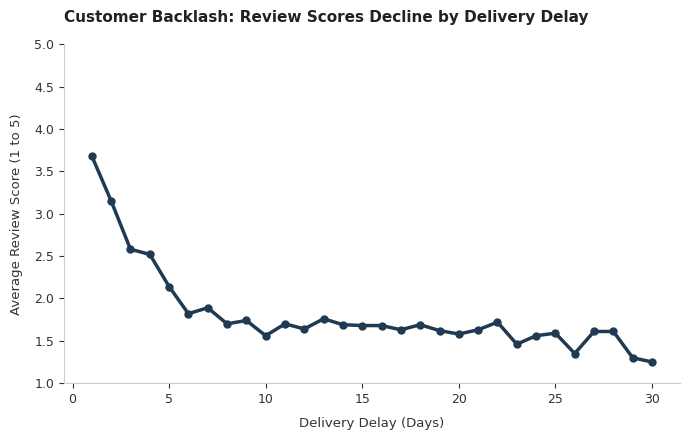

In [140]:
fig, ax = plt.subplots(figsize=(7, 4.5))

ax.plot(
    deli_df['delivery_delay_days'],
    deli_df['avg_review_score'],
    color='#1f3a52',
    linewidth=2.5,
    marker='o',
    markersize=5
)

ax.set_title('Customer Backlash: Review Scores Decline by Delivery Delay', fontsize=11, fontweight='bold', pad=16, loc='left', color='#222222')
ax.set_xlabel('Delivery Delay (Days)', fontsize=9.5, labelpad=8, color='#333333')
ax.set_ylabel('Average Review Score (1 to 5)', fontsize=9.5, labelpad=8, color='#333333')

ax.set_ylim(1.0, 5.0)

ax.grid(False)

ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#cccccc')

ax.tick_params(colors='#333333', labelsize=9)

plt.tight_layout()
plt.savefig('delay_days_vs_review_score.png', dpi=300)

In [141]:
duckdb.sql("""
SELECT
    seller_state,
    COUNT(*) as total_orders,
    ROUND(AVG(review_score),2) as avg_review,
    ROUND(MEDIAN(review_score),2) as median_review,
    ROUND(100 * SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) / COUNT(*),2) as LDR
FROM sales_reviewed
GROUP BY 1
HAVING COUNT(*) >= 100
ORDER BY LDR DESC
""").show()

┌──────────────┬──────────────┬────────────┬───────────────┬────────┐
│ seller_state │ total_orders │ avg_review │ median_review │  LDR   │
│   varchar    │    int64     │   double   │    double     │ double │
├──────────────┼──────────────┼────────────┼───────────────┼────────┤
│ MA           │          391 │       4.02 │           5.0 │  18.41 │
│ SP           │        77836 │       4.05 │           5.0 │   7.02 │
│ RJ           │         4638 │       4.17 │           5.0 │   6.75 │
│ DF           │          881 │       4.07 │           5.0 │   6.02 │
│ ES           │          359 │       4.07 │           5.0 │   5.57 │
│ PR           │         8418 │       4.13 │           5.0 │   5.19 │
│ SC           │         3963 │       4.13 │           5.0 │   4.77 │
│ MG           │         8508 │       4.17 │           5.0 │   4.58 │
│ BA           │          621 │       4.16 │           5.0 │   4.35 │
│ MT           │          144 │       4.19 │           5.0 │   4.17 │
│ RS           │    

SELLER ANALYSIS



In [142]:
duckdb.sql("""
SELECT * from sales_delivered limit 5
""").show()

┌──────────────────────────────────┬───────────────┬──────────────────────────────────┬──────────────────────────────────┬────────┬───────────────┬──────────────┬──────────────────────────┬──────────────────────────────┬───────────────────────────────┬───────────────────────────────┬───────────────────────┬───────────────────────────────┬──────────────┬──────────────┬──────────────────────────┬─────────────────────┬───────────────────┐
│             order_id             │ order_item_id │            product_id            │            seller_id             │ price  │ freight_value │ order_status │ order_purchase_timestamp │ order_delivered_carrier_date │ order_delivered_customer_date │ order_estimated_delivery_date │ product_category_name │ product_category_name_english │ seller_state │ review_score │ purchase_to_carrier_days │ delivery_delay_days │ transit_time_days │
│             varchar              │     int64     │             varchar              │             varchar             

In [143]:
duckdb.sql("""
SELECT
    seller_id,
    COUNT(*) as total_items_sold,
    ROUND(SUM(price), 2) as product_revenue,
    ROUND(AVG(price), 2) as avg_item_price
FROM sales_delivered
GROUP BY seller_id
ORDER BY product_revenue DESC
LIMIT 10
""").show()

┌──────────────────────────────────┬──────────────────┬─────────────────┬────────────────┐
│            seller_id             │ total_items_sold │ product_revenue │ avg_item_price │
│             varchar              │      int64       │     double      │     double     │
├──────────────────────────────────┼──────────────────┼─────────────────┼────────────────┤
│ 4869f7a5dfa277a7dca6462dcf3b52b2 │             1148 │       226987.93 │         197.72 │
│ 53243585a1d6dc2643021fd1853d8905 │              400 │       217940.44 │         544.85 │
│ 4a3ca9315b744ce9f8e9374361493884 │             1947 │       196735.72 │         101.05 │
│ fa1c13f2614d7b5c4749cbc52fecda94 │              579 │       190917.14 │         329.74 │
│ 7c67e1448b00f6e969d365cea6b010ab │             1354 │       186400.11 │         137.67 │
│ 7e93a43ef30c4f03f38b393420bc753a │              322 │       165981.49 │         515.47 │
│ da8622b14eb17ae2831f4ac5b9dab84a │             1546 │       159577.07 │         103.22 │

In [144]:
duckdb.sql("""
SELECT
    CASE
        WHEN total_orders BETWEEN 1 AND 10 THEN '01-10 orders'
        WHEN total_orders BETWEEN 11 AND 50 THEN '11-50 orders'
        WHEN total_orders BETWEEN 51 AND 100 THEN '51-100 orders'
        WHEN total_orders BETWEEN 101 AND 500 THEN '101-500 orders'
        ELSE '500+ orders'
    END as order_bucket,
    COUNT(*) as seller_count,
    ROUND(100.0 * SUM(total_late_orders) / SUM(total_orders), 2) as bucket_LDR
FROM (
    SELECT
        seller_id,
        COUNT(*) as total_orders,
        SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) as total_late_orders
    FROM sales_delivered
    GROUP BY seller_id
)
GROUP BY 1
ORDER BY MIN(total_orders)
""").show()

┌────────────────┬──────────────┬────────────┐
│  order_bucket  │ seller_count │ bucket_LDR │
│    varchar     │    int64     │   double   │
├────────────────┼──────────────┼────────────┤
│ 01-10 orders   │         1691 │       6.94 │
│ 11-50 orders   │          821 │       6.43 │
│ 51-100 orders  │          222 │       6.38 │
│ 101-500 orders │          202 │       6.55 │
│ 500+ orders    │           29 │       6.84 │
└────────────────┴──────────────┴────────────┘



> **Market Concentration:** Top 5% of sellers drive 53% of platform revenue—half the business depends on just 148 merchants.

In [145]:
duckdb.sql("""
select count(distinct seller_id) from sales_delivered
""").show()

┌───────────────────────────┐
│ count(DISTINCT seller_id) │
│           int64           │
├───────────────────────────┤
│                      2965 │
└───────────────────────────┘



In [146]:
concentration_df=duckdb.sql("""
WITH seller_revenue AS (
    SELECT
        seller_id,
        SUM(price) as total_revenue
    FROM sales_delivered
    GROUP BY seller_id
),
ranked_sellers AS (
    SELECT
        seller_id,
        total_revenue,
        RANK() OVER(ORDER BY total_revenue DESC) as seller_rank,
        COUNT(*) OVER() as total_sellers,
        SUM(total_revenue) OVER() as platform_total_revenue
    FROM seller_revenue
),
top5_pct AS (
    SELECT
        total_sellers,
        platform_total_revenue,
        COUNT(*) as top_sellers,
        SUM(total_revenue) as top_revenue
    FROM ranked_sellers
    WHERE seller_rank <= ROUND(0.05 * total_sellers, 0)
    GROUP BY total_sellers, platform_total_revenue
)
SELECT
    'Top 5% Sellers' AS seller_group,
    ROUND(100.0 * top_revenue / platform_total_revenue, 2) AS revenue_share_pct
FROM top5_pct

UNION ALL

SELECT
    'Remaining 95% Sellers' AS seller_group,
    ROUND(100.0 * (platform_total_revenue - top_revenue) / platform_total_revenue, 2) AS revenue_share_pct
FROM top5_pct
""").df()
concentration_df

,seller_group,revenue_share_pct
0,Top 5% Sellers,52.97
1,Remaining 95% Sellers,47.03


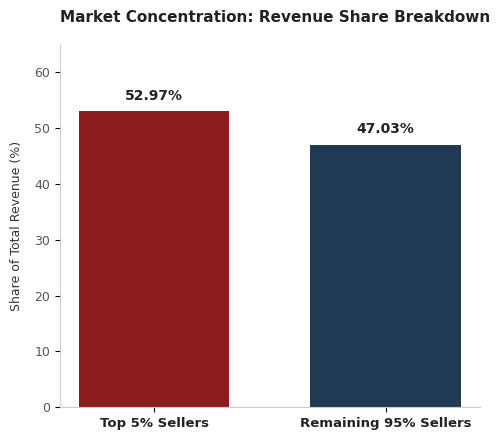

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4.5))

colors = ['#8e1c1c', '#1f3a52']
bars = plt.bar(
    concentration_df['seller_group'],
    concentration_df['revenue_share_pct'],
    color=colors,
    width=0.65
)

plt.title('Market Concentration: Revenue Share Breakdown', fontsize=11, fontweight='bold', pad=16, loc='left', color='#222222')
plt.ylabel('Share of Total Revenue (%)', fontsize=9, labelpad=8, color='#333333')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0,
        yval + 1.5,
        f'{yval}%',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='#222222'
    )

plt.grid(False)
plt.xticks(color='#222222', fontweight='bold', fontsize=9.5)
plt.yticks(color='#555555', fontsize=9)
plt.ylim(0, 65)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().spines[['left', 'bottom']].set_color('#cccccc')

plt.tight_layout()
plt.show()

In [148]:
duckdb.sql("""
SELECT
    seller_id,
    COUNT(*) as total_orders,
    ROUND(SUM(price), 2) as total_revenue,
    ROUND(AVG(review_score), 2) as avg_review,
    ROUND(100.0 * SUM(CASE WHEN delivery_delay_days > 0 THEN 1 ELSE 0 END) / COUNT(*), 2) as LDR
FROM sales_reviewed
GROUP BY seller_id
HAVING COUNT(*) >= 100
ORDER BY total_revenue DESC,avg_review ASC
LIMIT 20
""").show()

┌──────────────────────────────────┬──────────────┬───────────────┬────────────┬────────┐
│            seller_id             │ total_orders │ total_revenue │ avg_review │  LDR   │
│             varchar              │    int64     │    double     │   double   │ double │
├──────────────────────────────────┼──────────────┼───────────────┼────────────┼────────┤
│ 4869f7a5dfa277a7dca6462dcf3b52b2 │         1140 │     225586.34 │       4.14 │  10.44 │
│ 53243585a1d6dc2643021fd1853d8905 │          398 │     215904.44 │       4.13 │   2.76 │
│ 4a3ca9315b744ce9f8e9374361493884 │         1925 │     194552.72 │       3.83 │   9.71 │
│ fa1c13f2614d7b5c4749cbc52fecda94 │          575 │     189649.54 │       4.37 │    8.7 │
│ 7c67e1448b00f6e969d365cea6b010ab │         1346 │     185000.29 │       3.35 │   8.77 │
│ 7e93a43ef30c4f03f38b393420bc753a │          321 │      165751.5 │       4.36 │   4.36 │
│ da8622b14eb17ae2831f4ac5b9dab84a │         1540 │     158847.67 │       4.07 │   6.23 │
│ 7a67c85e

> **Single-Seller Risk:** State MA relies on just **1 single merchant** who handles all 398 orders but runs a massive **19.6% LDR**.

In [149]:
duckdb.sql("""
SELECT
    seller_state,
    COUNT(DISTINCT seller_id) as seller_count,
    COUNT(*) as total_orders,
    ROUND(COUNT(*) * 1.0 / COUNT(DISTINCT seller_id), 2) as orders_per_seller
FROM sales_delivered
GROUP BY seller_state
ORDER BY orders_per_seller DESC
""").show()

┌──────────────┬──────────────┬──────────────┬───────────────────┐
│ seller_state │ seller_count │ total_orders │ orders_per_seller │
│   varchar    │    int64     │    int64     │      double       │
├──────────────┼──────────────┼──────────────┼───────────────────┤
│ MA           │            1 │          398 │             398.0 │
│ PE           │            9 │          445 │             49.44 │
│ SP           │         1765 │        78433 │             44.44 │
│ MG           │          235 │         8575 │             36.49 │
│ MT           │            4 │          144 │              36.0 │
│ BA           │           18 │          623 │             34.61 │
│ DF           │           30 │          882 │              29.4 │
│ RJ           │          163 │         4678 │              28.7 │
│ PR           │          335 │         8472 │             25.29 │
│ SC           │          184 │         3989 │             21.68 │
│ RS           │          125 │         2164 │             17.

**CATEGORY ANALYSIS**

> **Strategic Note:** The top three revenue categories (Health & Beauty, Watches & Gifts, Bed & Bath) were the hardest hit during the March–April 2018 shipping crisis, with late delivery rates hitting 16% to 20%.

In [150]:
duckdb.sql("""
SELECT
    sd.product_category_name_english,
    COUNT(*) as total_orders,
    ROUND(SUM(sd.price), 2) as total_revenue,
    ROUND(AVG(sd.price), 2) as avg_item_value,
    ROUND(AVG(sr.review_score), 2) as avg_review,
    ROUND(MEDIAN(sr.review_score), 2) as median_review
FROM sales_delivered sd
LEFT JOIN sales_reviewed sr
    ON sd.order_id = sr.order_id
    AND sd.order_item_id = sr.order_item_id
WHERE sd.product_category_name_english != 'unknown'
GROUP BY sd.product_category_name_english
ORDER BY total_revenue DESC
LIMIT 10
""").show()

┌───────────────────────────────┬──────────────┬───────────────┬────────────────┬────────────┬───────────────┐
│ product_category_name_english │ total_orders │ total_revenue │ avg_item_value │ avg_review │ median_review │
│            varchar            │    int64     │    double     │     double     │   double   │    double     │
├───────────────────────────────┼──────────────┼───────────────┼────────────────┼────────────┼───────────────┤
│ health_beauty                 │         9447 │    1231510.16 │         130.36 │       4.19 │           5.0 │
│ watches_gifts                 │         5846 │    1163762.82 │         199.07 │       4.07 │           5.0 │
│ bed_bath_table                │        10929 │    1021560.81 │          93.47 │       3.92 │           5.0 │
│ sports_leisure                │         8414 │     952933.61 │         113.26 │       4.16 │           5.0 │
│ computers_accessories         │         7631 │     887550.11 │         116.31 │       3.99 │           5.0 │
│

> **The Logistics Backlash:** Categories with severe 2018 peak delays—like Bed & Bath (17.5% LDR) and Telephony (16.7% LDR)—now rank among the platform's absolute worst-reviewed overall (under 4.0).

In [151]:
duckdb.sql("""
SELECT
    product_category_name_english,
    COUNT(*) as total_orders,
    ROUND(SUM(price), 2) as total_revenue,
    ROUND(AVG(price), 2) as avg_item_value,
    ROUND(AVG(review_score), 2) as avg_review
FROM sales_reviewed
WHERE product_category_name_english != 'unknown'
GROUP BY product_category_name_english
HAVING COUNT(*) >= 500
ORDER BY avg_review ASC
LIMIT 10
""").show()

┌───────────────────────────────┬──────────────┬───────────────┬────────────────┬────────────┐
│ product_category_name_english │ total_orders │ total_revenue │ avg_item_value │ avg_review │
│            varchar            │    int64     │    double     │     double     │   double   │
├───────────────────────────────┼──────────────┼───────────────┼────────────────┼────────────┤
│ office_furniture              │         1653 │      265099.7 │         160.37 │       3.51 │
│ bed_bath_table                │        10807 │    1011716.77 │          93.62 │       3.92 │
│ furniture_decor               │         8053 │     703250.78 │          87.33 │       3.95 │
│ home_construction             │          591 │      81085.26 │          137.2 │       3.96 │
│ computers_accessories         │         7595 │     883586.46 │         116.34 │       3.99 │
│ telephony                     │         4399 │      307649.8 │          69.94 │       3.99 │
│ watches_gifts                 │         5802 │  

> **Electronics Freight Tax:** Electronics carries the platform's highest freight burden (29.5%), heavily penalizing a lower-average-value category.

In [152]:
duckdb.sql("""
SELECT
    product_category_name_english,
    COUNT(*) as total_orders,
    ROUND(AVG(price), 2) as avg_price,
    ROUND(AVG(freight_value), 2) as avg_freight,
    ROUND(100.0 * SUM(freight_value) / SUM(price), 2) as freight_to_price_pct
FROM sales_delivered
WHERE product_category_name_english != 'unknown'
GROUP BY product_category_name_english
HAVING COUNT(*) >= 500
ORDER BY freight_to_price_pct DESC
LIMIT 10
""").show()

┌───────────────────────────────┬──────────────┬───────────┬─────────────┬──────────────────────┐
│ product_category_name_english │ total_orders │ avg_price │ avg_freight │ freight_to_price_pct │
│            varchar            │    int64     │  double   │   double    │        double        │
├───────────────────────────────┼──────────────┼───────────┼─────────────┼──────────────────────┤
│ electronics                   │         2724 │     56.78 │       16.75 │                29.49 │
│ office_furniture              │         1667 │    160.76 │       40.18 │                24.99 │
│ furniture_decor               │         8133 │      87.2 │       20.64 │                23.68 │
│ housewares                    │         6773 │      90.7 │       21.02 │                23.18 │
│ telephony                     │         4425 │     69.99 │       15.66 │                22.37 │
│ luggage_accessories           │         1071 │    128.84 │       27.92 │                21.67 │
│ garden_tools      

> **Hyper-Growth Sectors:** Electronics and Watches/Gifts are expanding rapidly, leading platform growth at **395%** and **331%** year-over-year, which significantly intensifies fulfillment pressure on these supply chains.

In [153]:
category_growth_df = duckdb.sql("""
SELECT
    product_category_name_english,
    SUM(CASE WHEN YEAR(order_purchase_timestamp) = 2017 THEN 1 ELSE 0 END) as orders_2017,
    SUM(CASE WHEN YEAR(order_purchase_timestamp) = 2018 THEN 1 ELSE 0 END) as orders_2018,
    ROUND(100.0 * (SUM(CASE WHEN YEAR(order_purchase_timestamp) = 2018 THEN 1 ELSE 0 END) -
    SUM(CASE WHEN YEAR(order_purchase_timestamp) = 2017 THEN 1 ELSE 0 END)) /
    NULLIF(SUM(CASE WHEN YEAR(order_purchase_timestamp) = 2017 THEN 1 ELSE 0 END), 0), 2) as growth_pct
FROM sales_delivered
WHERE product_category_name_english != 'unknown' AND MONTH(order_purchase_timestamp) BETWEEN 1 AND 8
GROUP BY product_category_name_english
HAVING orders_2017 >= 100
ORDER BY growth_pct DESC
LIMIT 10
""").df()
category_growth_df

,product_category_name_english,orders_2017,orders_2018,growth_pct
0,electronics,370.0,1833.0,395.41
1,watches_gifts,838.0,3616.0,331.50
2,stationery,383.0,1494.0,290.08
3,auto,773.0,2562.0,231.44
4,health_beauty,1820.0,5825.0,220.05
5,musical_instruments,129.0,392.0,203.88
6,home_appliances,177.0,518.0,192.66
7,baby,596.0,1726.0,189.60
8,computers_accessories,1656.0,4611.0,178.44
9,pet_shop,456.0,1144.0,150.88


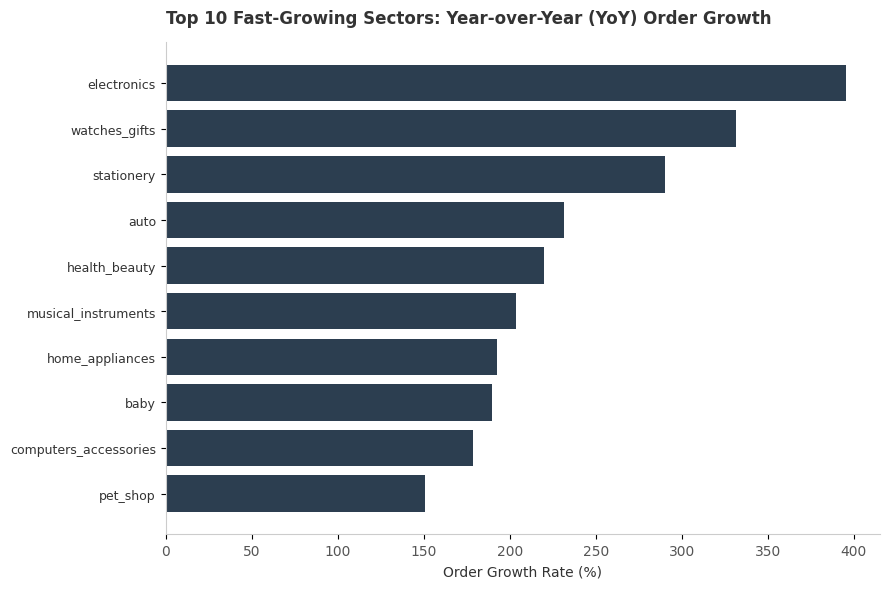

In [154]:
plt.figure(figsize=(9, 6))

df_sorted = category_growth_df.iloc[::-1]

plt.barh(df_sorted['product_category_name_english'], df_sorted['growth_pct'], color='#2c3e50', height=0.8)

plt.title('Top 10 Fast-Growing Sectors: Year-over-Year (YoY) Order Growth', fontsize=12, fontweight='bold', pad=14, loc='left', color='#333333')
plt.xlabel('Order Growth Rate (%)', fontsize=10, labelpad=5, color='#333333')

plt.xticks(color='#555555')
plt.yticks(color='#333333', fontsize=9)
plt.grid(False)

plt.gca().spines[['top', 'right']].set_visible(False)
plt.gca().spines[['left', 'bottom']].set_color('#cccccc')

plt.tight_layout()
plt.show()

**REVIEW ANALYSIS**

In [155]:
duckdb.sql("""
SELECT * FROM sales_reviewed LIMIT 5
""").show()

┌──────────────────────────────────┬───────────────┬──────────────────────────────────┬──────────────────────────────────┬────────┬───────────────┬──────────────┬──────────────────────────┬──────────────────────────────┬───────────────────────────────┬───────────────────────────────┬───────────────────────────────────┬─────────────────────────────────┬──────────────┬──────────────┬──────────────────────────┬─────────────────────┬───────────────────┐
│             order_id             │ order_item_id │            product_id            │            seller_id             │ price  │ freight_value │ order_status │ order_purchase_timestamp │ order_delivered_carrier_date │ order_delivered_customer_date │ order_estimated_delivery_date │       product_category_name       │  product_category_name_english  │ seller_state │ review_score │ purchase_to_carrier_days │ delivery_delay_days │ transit_time_days │
│             varchar              │     int64     │             varchar              │     

> **Review Breakdown:** Around 76% of orders get a positive 4 or 5-star rating, but 1-star reviews still make up 11.36% of the platform.

In [156]:
duckdb.sql("""
SELECT
    ROUND(review_score) as review_score,
    COUNT(*) as total_reviews,
    ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER(), 2) as percentage
FROM sales_reviewed
GROUP BY 1
ORDER BY 1
""").show()

┌──────────────┬───────────────┬────────────┐
│ review_score │ total_reviews │ percentage │
│    double    │     int64     │   double   │
├──────────────┼───────────────┼────────────┤
│          1.0 │         12397 │      11.36 │
│          2.0 │          3670 │       3.36 │
│          3.0 │          9225 │       8.45 │
│          4.0 │         21019 │      19.26 │
│          5.0 │         62817 │      57.56 │
└──────────────┴───────────────┴────────────┘



> **Key Trend:** There is a gradual downward trend in satisfaction as order value increases. While still generally positive, the average review score declines from 4.25 (Under $50)  to 4.00 (Over $500), suggesting that higher financial spend slightly correlates with tighter customer expectations.

In [157]:
duckdb.sql("""
WITH total_order_spend AS (
    SELECT
        order_id,
        SUM(price + freight_value) as total_spent,
        AVG(review_score) as avg_order_review
    FROM sales_reviewed
    GROUP BY order_id
)
SELECT
    CASE
        WHEN total_spent < 50 THEN '1. Under $50'
        WHEN total_spent BETWEEN 50 AND 100 THEN '2. $50-$100'
        WHEN total_spent BETWEEN 100.01 AND 200 THEN '3. $101-$200'
        WHEN total_spent BETWEEN 200.01 AND 500 THEN '4. $201-$500'
        ELSE '5. Over $500'
    END as order_value_bucket,
    COUNT(*) as total_orders,
    ROUND(AVG(avg_order_review), 2) as avg_review
FROM total_order_spend
GROUP BY 1
ORDER BY 1
""").show()

┌────────────────────┬──────────────┬────────────┐
│ order_value_bucket │ total_orders │ avg_review │
│      varchar       │    int64     │   double   │
├────────────────────┼──────────────┼────────────┤
│ 1. Under $50       │        16359 │       4.25 │
│ 2. $50-$100        │        29219 │       4.19 │
│ 3. $101-$200       │        30726 │       4.14 │
│ 4. $201-$500       │        15304 │       4.05 │
│ 5. Over $500       │         4029 │        4.0 │
└────────────────────┴──────────────┴────────────┘



> **Review Breakdown:** Multi-item orders have a much lower average rating (3.64) than single-item orders (4.21), despite having a much higher AOV.

In [158]:
duckdb.sql("""
WITH order_item_counts AS (
    SELECT
        order_id,
        MAX(order_item_id) as total_items_in_order,
        AVG(review_score) as avg_order_review,
        SUM(price + freight_value) as total_order_value
    FROM sales_reviewed
    GROUP BY order_id
)
SELECT
    CASE
        WHEN total_items_in_order = 1 THEN 'Single Item'
        ELSE 'Multi Item'
    END as order_type,
    COUNT(*) as total_orders,
    ROUND(AVG(avg_order_review), 2) as avg_review,
    ROUND(AVG(total_order_value), 2) as AOV
FROM order_item_counts
GROUP BY 1
ORDER BY 1
""").show()

┌─────────────┬──────────────┬────────────┬────────┐
│ order_type  │ total_orders │ avg_review │  AOV   │
│   varchar   │    int64     │   double   │ double │
├─────────────┼──────────────┼────────────┼────────┤
│ Multi Item  │         9498 │       3.64 │ 248.32 │
│ Single Item │        86139 │       4.21 │  149.8 │
└─────────────┴──────────────┴────────────┴────────┘



> **Review Breakdown:** Average review scores dropped to their lowest levels in March 2018 (3.81) and April 2018 (3.79), directly matching the months where late delivery rates peaked.

In [159]:
duckdb.sql("""
SELECT
    STRFTIME(order_delivered_customer_date, '%Y-%m') as delivery_month,
    COUNT(*) as total_reviews,
    ROUND(AVG(review_score), 2) as avg_review
FROM sales_reviewed
WHERE order_delivered_customer_date >= '2017-01-01'
  AND order_delivered_customer_date < '2018-09-01'
GROUP BY 1
ORDER BY 1
""").show()

┌────────────────┬───────────────┬────────────┐
│ delivery_month │ total_reviews │ avg_review │
│    varchar     │     int64     │   double   │
├────────────────┼───────────────┼────────────┤
│ 2017-01        │           324 │       4.18 │
│ 2017-02        │          1551 │       4.29 │
│ 2017-03        │          2698 │       4.21 │
│ 2017-04        │          2058 │       4.09 │
│ 2017-05        │          4179 │       4.14 │
│ 2017-06        │          3605 │       4.19 │
│ 2017-07        │          3871 │       4.21 │
│ 2017-08        │          4864 │       4.27 │
│ 2017-09        │          4430 │       4.23 │
│ 2017-10        │          5180 │       4.13 │
│ 2017-11        │          5375 │       4.11 │
│ 2017-12        │          8237 │       3.99 │
│ 2018-01        │          7352 │       3.94 │
│ 2018-02        │          6560 │       4.01 │
│ 2018-03        │          7898 │       3.81 │
│ 2018-04        │          8920 │       3.79 │
│ 2018-05        │          8082 │      